In [129]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

df = pd.read_csv("adult.csv")

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,?,77053,HS-grad,9,Widowed,?,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,?,186061,Some-college,10,Widowed,?,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K


In [145]:

df.head(5)

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,?,77053,HS-grad,9,Widowed,?,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,?,186061,Some-college,10,Widowed,?,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K


In [130]:
columnas_objetivo = [
    "age",
    "capital.gain",
    "capital.loss",
    "hours.per.week"
]

df_modelo = df[columnas_objetivo]

df_modelo.head()

,age,capital.gain,capital.loss,hours.per.week
0,90,0,4356,40
1,82,0,4356,18
2,66,0,4356,40
3,54,0,3900,40
4,41,0,3900,40


In [131]:
nulos = df.isnull().sum()
print(nulos)

age               0
workclass         0
fnlwgt            0
education         0
education.num     0
marital.status    0
occupation        0
relationship      0
race              0
sex               0
capital.gain      0
capital.loss      0
hours.per.week    0
native.country    0
income            0
dtype: int64


In [132]:
indices_a_borrar = df_modelo[df_modelo["capital.gain"] == 0].index
df_modelo.drop(indices_a_borrar, inplace=True)

df_modelo.head()

/tmp/ipykernel_8936/3896444491.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_modelo.drop(indices_a_borrar, inplace=True)


,age,capital.gain,capital.loss,hours.per.week
1519,54,99999,0,60
1520,52,99999,0,40
1521,53,99999,0,40
1522,52,99999,0,50
1523,46,99999,0,60


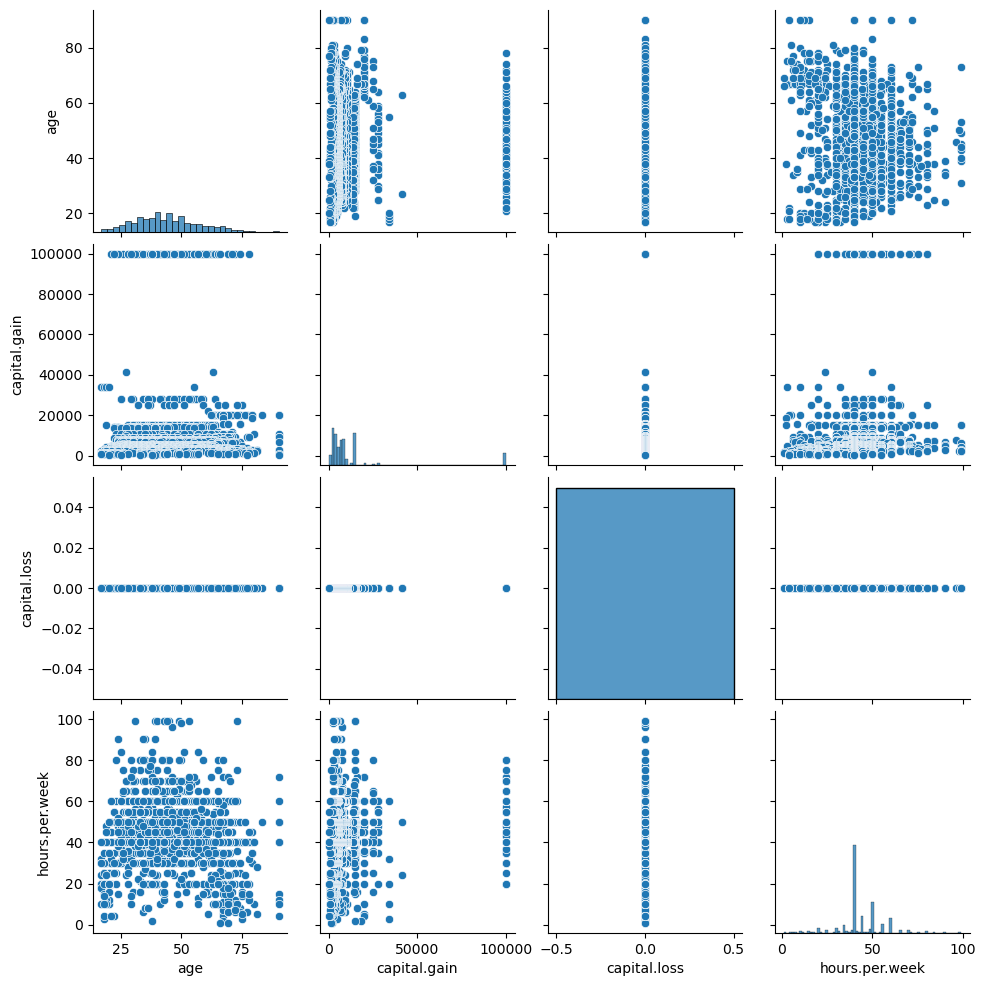

In [133]:
import seaborn as sns

sns.pairplot(df_modelo)

In [134]:
from sklearn.model_selection import train_test_split

X = df_modelo.drop('hours.per.week', axis=1)
y = df_modelo['hours.per.week'].to_frame()


In [135]:
X

,age,capital.gain,capital.loss
1519,54,99999,0
1520,52,99999,0
1521,53,99999,0
1522,52,99999,0
1523,46,99999,0
...,...,...,...
4226,20,114,0
4227,39,114,0
4228,33,114,0
4229,38,114,0


In [136]:
y

,hours.per.week
1519,60
1520,40
1521,40
1522,50
1523,60
...,...
4226,20
4227,45
4228,55
4229,40


In [137]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.20, random_state = 0)

In [138]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train, y_train)

LinearRegression()

In [139]:
lr.coef_

array([[-9.56558910e-02,  9.11491574e-05,  0.00000000e+00]])

In [140]:
lr.intercept_

array([46.34613914])

In [141]:
y_pred = lr.predict(X_test)

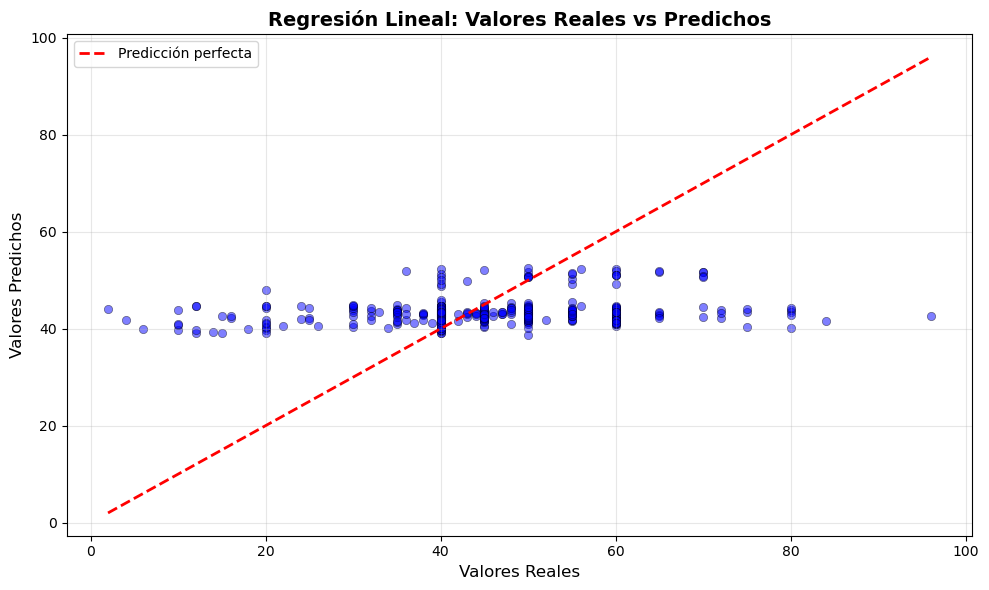

In [142]:
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.5, color='blue', edgecolors='black', linewidth=0.5)
plt.plot([y_test.min(), y_test.max()], 
         [y_test.min(), y_test.max()], 
         'r--', lw=2, label='Predicción perfecta')
plt.xlabel('Valores Reales', fontsize=12)
plt.ylabel('Valores Predichos', fontsize=12)
plt.title('Regresión Lineal: Valores Reales vs Predichos', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [143]:
from sklearn.metrics import mean_squared_error as MSE

In [144]:
from sklearn.metrics import r2_score
r2_score(y_test, y_pred)

0.0498557317854208